In [10]:

install.packages("markovchain", dependencies=TRUE, repos='http://cran.rstudio.com/')


library(markovchain)

options(repr.plot.width=8, repr.plot.height=6)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Chain A1  Markov chain that is composed by: 
Closed classes: 
S1 
Recurrent classes: 
{S1}
Transient classes: 
{S2,S3,S4,S5}
The Markov chain is not irreducible 
The absorbing states are: S1
 [1] "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1"
[16] "S1" "S1" "S1" "S1" "S1"
 [1] "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1"
[16] "S1" "S1" "S1" "S1" "S1"
 [1] "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1" "S1"
[16] "S1" "S1" "S1" "S1" "S1"
     S1 S2 S3 S4 S5
[1,]  1  0  0  0  0


[1] FALSE

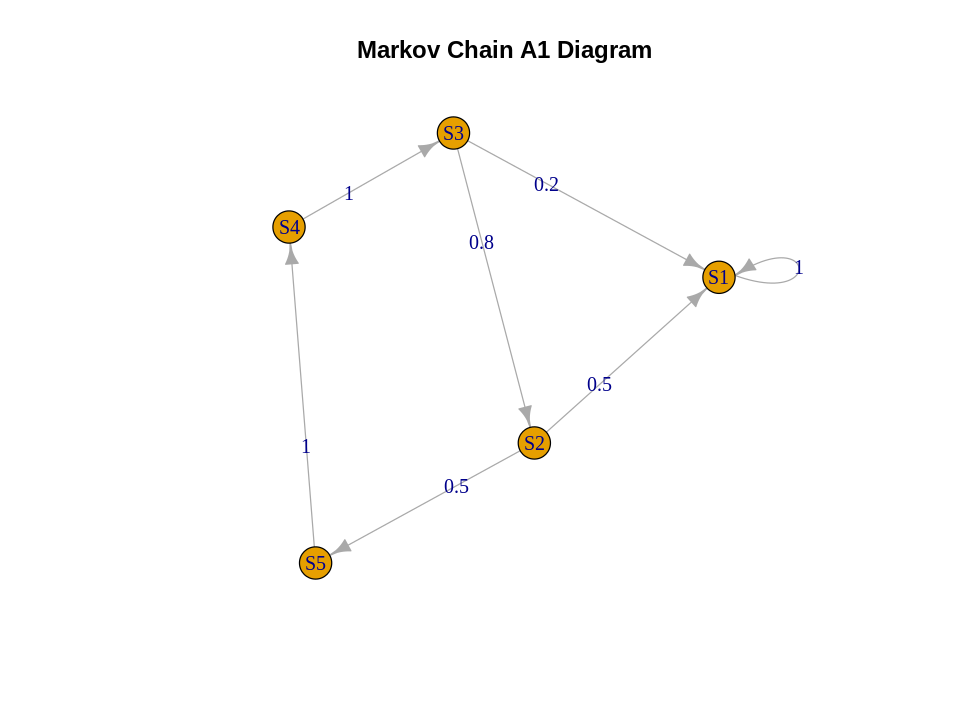

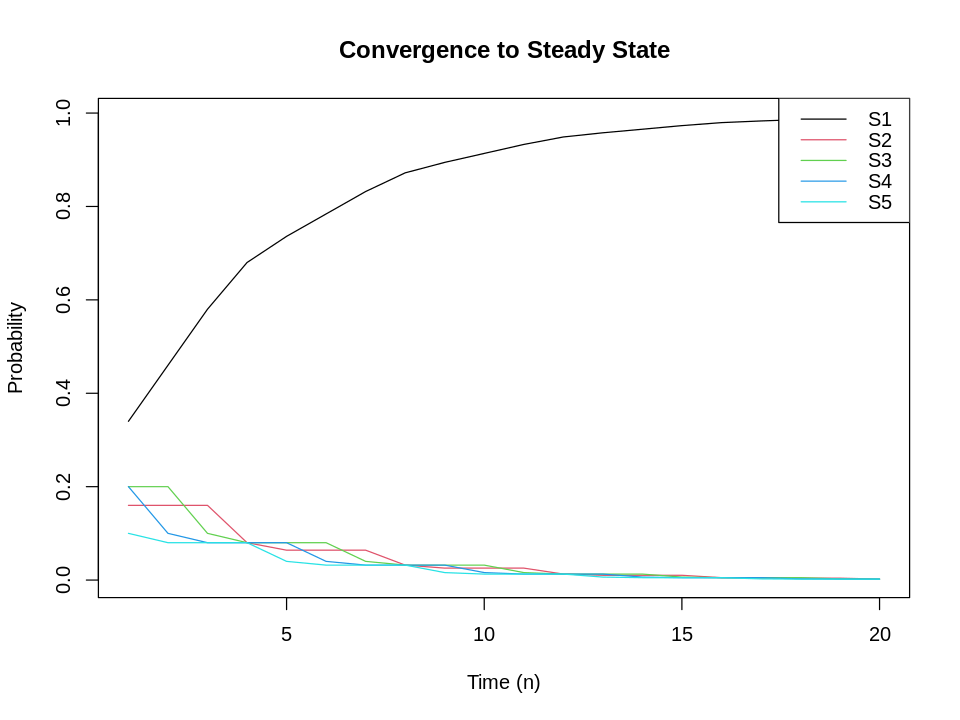

In [11]:
# Question A1
library(markovchain)

# Define the state space
states_A1 <- c("S1", "S2", "S3", "S4", "S5")

P1_values <- c(1.0, 0, 0, 0, 0,
               0.5, 0, 0, 0, 0.5,
               0.2, 0.8, 0, 0, 0,
               0, 0, 1.0, 0, 0,
               0, 0, 0, 1.0, 0)

P1 <- matrix(P1_values, nrow = 5, byrow = TRUE, dimnames = list(states_A1, states_A1))
mcA1 <- new("markovchain", states = states_A1, transitionMatrix = P1, name = "Chain A1")

# (a) Plot diagram and identify classes, absorbing/reflecting states, and periods
plot(mcA1, main="Markov Chain A1 Diagram")
summary(mcA1) # This outputs transient/recurrent classes, absorbing states, and periodicity

# (b) Simulate three trajectories
# Simulating 20 steps for 3 different trajectories
set.seed(123)
sim1 <- rmarkovchain(n = 20, object = mcA1)
sim2 <- rmarkovchain(n = 20, object = mcA1)
sim3 <- rmarkovchain(n = 20, object = mcA1)
print(sim1); print(sim2); print(sim3)


# (c) Steady-state probabilities and ergodicity
steady_states_A1 <- steadyStates(mcA1)
print(steady_states_A1)
is.accessible(mcA1, "S1", "S5")
# An ergodic chain must be irreducible and aperiodic.

# (d) Unconditional probabilities against time
initial_state <- c(0.2, 0.2, 0.2, 0.2, 0.2) # Assuming uniform start
n_steps <- 20
probs <- matrix(NA, nrow = n_steps, ncol = 5)
for(i in 1:n_steps) {
  probs[i, ] <- initial_state * (mcA1 ^ i)
}
matplot(1:n_steps, probs, type = "l", lty = 1, col = 1:5,
        xlab = "Time (n)", ylab = "Probability", main = "Convergence to Steady State")
legend("topright", legend = states_A1, col = 1:5, lty = 1)

Chain A2  Markov chain that is composed by: 
Closed classes: 
1 2 
Recurrent classes: 
{1,2}
Transient classes: 
{3},{4,5,6,7}
The Markov chain is not irreducible 
The absorbing states are: NONE
 [1] "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2"
[20] "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1"
 [1] "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2" "1"
[20] "2" "1" "2" "1" "2" "1" "2" "1" "2" "1" "2"
       1   2 3 4 5 6 7
[1,] 0.5 0.5 0 0 0 0 0


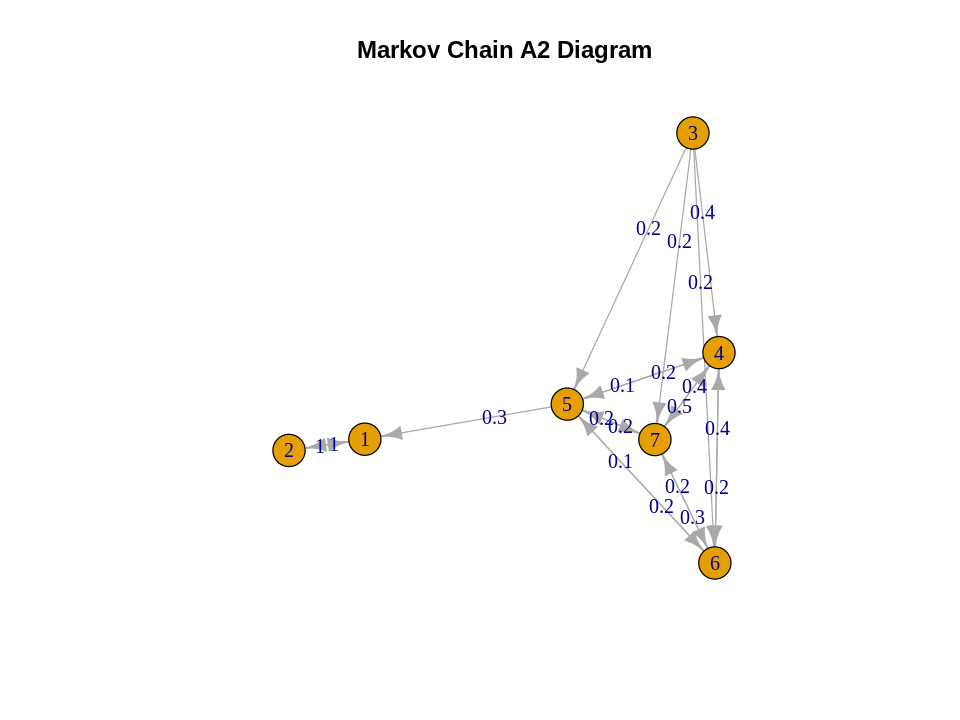

In [12]:
# Question A2
states_A2 <- c("1", "2", "3", "4", "5", "6", "7")

# Define the matrix based on the provided text
P2_values <- c(0, 1, 0, 0, 0, 0, 0,
               1, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 0.4, 0.2, 0.2, 0.2,
               0, 0, 0, 0, 0.2, 0.4, 0.4,
               0.3, 0, 0, 0.1, 0.3, 0.1, 0.2,
               0, 0, 0, 0.2, 0.2, 0.3, 0.3,
               0, 0, 0, 0.5, 0.2, 0.2, 0.1)

P2 <- matrix(P2_values, nrow = 7, byrow = TRUE, dimnames = list(states_A2, states_A2))
mcA2 <- new("markovchain", states = states_A2, transitionMatrix = P2, name = "Chain A2")

# (a) Plot the diagram
plot(mcA2, main="Markov Chain A2 Diagram")

# (b) Identify recurrent/transient classes, periods, absorbing/reflecting states
summary(mcA2)

# (c) Simulate two trajectories
set.seed(42)
traj1 <- rmarkovchain(n = 30, object = mcA2, t0 = sample(states_A2, 1))
traj2 <- rmarkovchain(n = 30, object = mcA2, t0 = sample(states_A2, 1))
print(traj1); print(traj2)

# (d) Calculate limiting probabilities
steady_states_A2 <- steadyStates(mcA2)
print(steady_states_A2)
# If the chain has multiple closed communicating classes, steady states may depend on the starting state. The chain is only ergodic if it is irreducible and aperiodic.

[1] "Distribution at 6 PM:"
          light    heavy    jammed
[1,] 0.01480077 0.132596 0.8526032


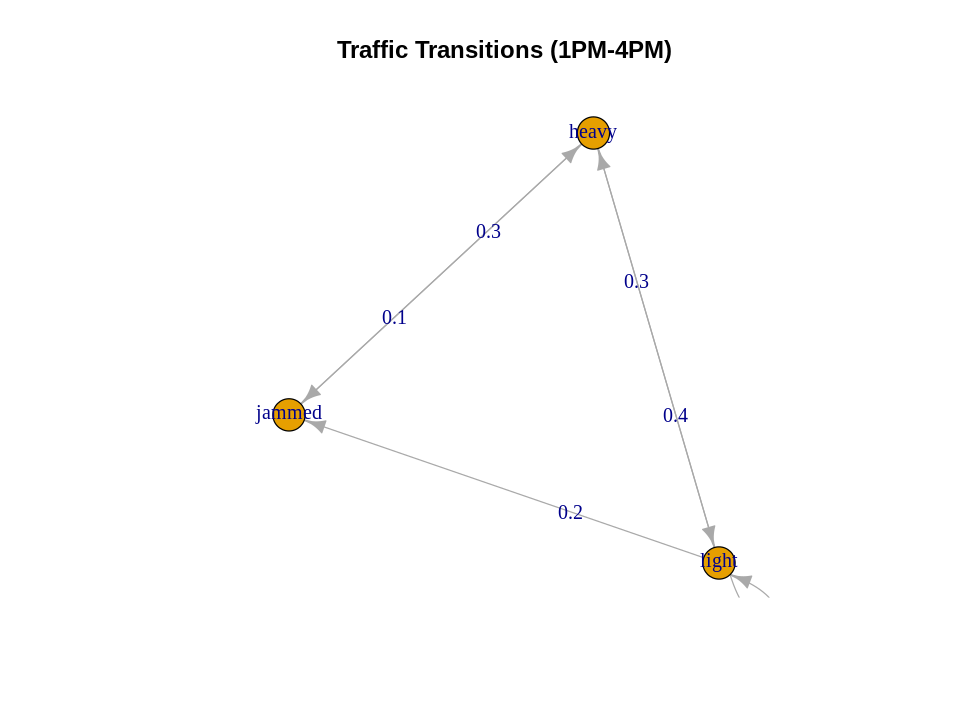

In [14]:
# Question A3
states_traffic <- c("light", "heavy", "jammed")

# 1 PM to 4 PM Matrix
P1 <- matrix(c(0.4, 0.4, 0.2,
               0.3, 0.4, 0.3,
               0, 0.1, 0.9), nrow=3, byrow=TRUE, dimnames=list(states_traffic, states_traffic))
mc1 <- new("markovchain", transitionMatrix=P1)

# 4 PM to 6 PM Matrix
P2 <- matrix(c(0.1, 0.5, 0.4,
               0.1, 0.3, 0.6,
               0, 0.1, 0.9), nrow=3, byrow=TRUE, dimnames=list(states_traffic, states_traffic))
mc2 <- new("markovchain", transitionMatrix=P2)

# Calculation for Part (a) [cite: 29]
initial_state <- c(1, 0, 0) # Starts at 'light' [cite: 29]
# 9 intervals of 20 mins (1PM-4PM) and 6 intervals (4PM-6PM)
final_dist <- initial_state * (mc1 ^ 9) * (mc2 ^ 6)

print("Distribution at 6 PM:")
print(final_dist)

# Plotting the first transition matrix [cite: 19]
plot(mc1, main="Traffic Transitions (1PM-4PM)")